# 03 — FN-Reduction Tuning (inference-time, no retrain)

Baseline `arm_gold-2` บน test split — ลองทุกเทคนิคลด FN จาก literature:
- inference resolution sweep (640/960/1280)
- manual flip-TTA (built-in `augment=True` ไม่รองรับ YOLO26-seg)
- NMS variants: `nms=False` (one-to-one head), NMS-IoU 0.4
- temporal **attention-area boost** (Kaggle GBR trick — เฟรมก่อน boost เฟรมหลัง)
- per-class conf sweep (sand)
- union-ensemble (multi-scale + multi-model + SAHI tiling)
- per-instance rescoring

Preds ทุก config cache ลง `results/preds_cache/` — รันซ้ำเร็ว.
Metrics: custom mask AP50-95 (strict + sieved), TP/FP/FN @conf0.25.

In [1]:
import numpy as np, cv2, pandas as pd, pickle, time
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

WORK = Path('.').resolve()           # experiment/
TI = WORK/'data/gold/test/images'; TL = WORK/'data/gold/test/labels'
CACHE_DIR = WORK/'results/preds_cache'; CACHE_DIR.mkdir(parents=True, exist_ok=True)
CKPT = WORK/'runs/arm_gold-2/weights/best.pt'
CKPT960 = WORK/'runs/arm_clean960/weights/best.pt'
NAMES = {0:'gravel', 1:'sand'}
AREA_MIN, ASP = 0.005, 8.0          # sieve rule
IOUS = np.round(np.arange(0.5,1.0,0.05),2)
model = YOLO(str(CKPT))
print('ready', TI.exists(), CKPT.exists())

ready True True


In [2]:
def sieve(g): return g['area']>=AREA_MIN and g['aspect']<=ASP

def load_gt(lf, W, H):
    out=[]
    if not lf.exists(): return out
    for ln in lf.read_text().strip().splitlines():
        p=ln.split()
        if len(p)<7: continue
        xy=np.array(p[1:],float).reshape(-1,2)
        px=(xy*[W,H]).astype(np.int32)
        m=np.zeros((H,W),np.uint8); cv2.fillPoly(m,[px],1)
        bw,bh=np.ptp(px[:,0]),np.ptp(px[:,1])
        out.append(dict(cls=int(p[0]),mask=m.astype(bool),
                        area=float(m.mean()),aspect=float(max(bw,bh)/max(1,min(bw,bh)))))
    return out

GT={}; SHW={}
for ip in sorted(TI.glob('*.jpg')):
    im=cv2.imread(str(ip)); H,W=im.shape[:2]; SHW[ip.name]=(W,H)
    GT[ip.name]=load_gt(TL/(ip.stem+'.txt'),W,H)
print('test imgs:',len(GT),'| GT insts:',sum(len(v) for v in GT.values()),
      '| sieved-out:',sum(1 for v in GT.values() for g in v if not sieve(g)))

test imgs: 105 | GT insts: 348 | sieved-out: 79


In [3]:
def _pack(pr):
    return dict(cls=np.array([p['cls'] for p in pr],np.int8),
                conf=np.array([p['conf'] for p in pr],np.float32),
                masks=np.stack([np.packbits(p['mask'],axis=None) for p in pr])
                       if pr else np.zeros((0,),np.uint8),
                n=np.array([len(pr)]))

def _unpack(d, WH):
    n=int(d['n']); W,H=WH
    if n==0: return []
    flat=np.unpackbits(d['masks'],axis=1)[:,:H*W]
    return [dict(cls=int(c),conf=float(cf),mask=m.reshape(H,W))
            for c,cf,m in zip(d['cls'],d['conf'],flat)]

def predict_cfg(tag, model_obj=None, imgsz=640, iou_nms=0.7, nms=True, flip=False):
    f = CACHE_DIR/f'{tag}.npz'
    if f.exists():
        d=np.load(f,allow_pickle=True)
        return {nm:_unpack(d[f'k{i}'].item(),SHW[nm])
                for i,nm in enumerate(d['names'])}
    m = model_obj or model
    out={}
    for nm,(W,H) in SHW.items():
        im = cv2.imread(str(TI/nm))
        if flip: im = cv2.flip(im,1)
        r = m.predict(im,imgsz=imgsz,conf=0.001,iou=iou_nms,nms=nms,
                      device=0,retina_masks=True,verbose=False)[0]
        pr=[]
        if r.masks is not None:
            for c,cf,mm in zip(r.boxes.cls.cpu().numpy().astype(int),
                               r.boxes.conf.cpu().numpy(),
                               r.masks.data.cpu().numpy()):
                mk = cv2.resize(mm,(W,H))>0.5
                if flip: mk = np.fliplr(mk)
                if mk.any(): pr.append(dict(cls=int(c),conf=float(cf),mask=mk))
        out[nm]=pr
    names=list(out)
    np.savez_compressed(f, names=np.array(names),
                        **{f'k{i}':_pack(out[nm]) for i,nm in enumerate(names)})
    print(f'[cache] {tag}: predicted+saved ({len(names)} imgs)',flush=True)
    return out

In [4]:
def iou(a,b):
    u=(a|b).sum(); return (a&b).sum()/u if u else 0.

def evaluate(PR, sieved=True, conf_op=0.25, per_cls_conf=None):
    aps=[]
    for cls in (0,1):
        n_gt=sum(1 for im in GT.values() for g in im
                 if g['cls']==cls and (not sieved or sieve(g)))
        aa=[]
        for thr in IOUS:
            recs=[]
            for nm in GT:
                keep=[g for g in GT[nm] if g['cls']==cls and (not sieved or sieve(g))]
                used=set()
                for p in sorted([p for p in PR[nm] if p['cls']==cls
                                 and (not sieved or p['mask'].mean()>=AREA_MIN)],
                                key=lambda x:-x['conf']):
                    best,bj=0.,-1
                    for j,g in enumerate(keep):
                        if j in used: continue
                        v=iou(p['mask'],g['mask'])
                        if v>best: best,bj=v,j
                    if best>=thr: used.add(bj); recs.append((p['conf'],1))
                    else: recs.append((p['conf'],0))
            if n_gt==0: aa.append(np.nan); continue
            recs.sort(key=lambda x:-x[0])
            tp=np.cumsum([r[1] for r in recs]); fp=np.cumsum([1-r[1] for r in recs])
            rec=tp/n_gt; prec=np.divide(tp,np.maximum(tp+fp,1))
            mrec=np.concatenate([[0],rec,[1]]); mpre=np.concatenate([[0],prec,[0]])
            for i in range(len(mpre)-2,-1,-1): mpre[i]=max(mpre[i],mpre[i+1])
            aa.append(mpre[np.minimum(np.searchsorted(mrec,np.linspace(0,1,101),'left'),
                                     len(mpre)-1)].mean())
        aps.append(float(np.nanmean(aa)))
    tp=fp=fn=0
    for nm in GT:
        used=set()
        keep=[g for g in GT[nm] if not sieved or sieve(g)]
        for p in PR[nm]:
            cth=(per_cls_conf or {}).get(p['cls'],conf_op)
            if p['conf']<cth or (sieved and p['mask'].mean()<AREA_MIN): continue
            best,bj=0.,-1
            for j,g in enumerate(keep):
                if j in used or g['cls']!=p['cls']: continue
                v=iou(p['mask'],g['mask'])
                if v>best: best,bj=v,j
            if best>=0.5: used.add(bj); tp+=1
            else: fp+=1
        fn+=len(keep)-len(used)
    return dict(mAP=round(np.nanmean(aps),4),gravel=round(aps[0],4),
                sand=round(aps[1],4),TP=tp,FP=fp,FN=fn)

ROWS=[]
def run(tag, PR, **kw):
    s=evaluate(PR,sieved=False,**kw); v=evaluate(PR,sieved=True,**kw)
    ROWS.append(dict(config=tag,strict=s['mAP'],sieved=v['mAP'],
                     sand_strict=s['sand'],TP=v['TP'],FP=v['FP'],FN=v['FN']))
    print(f"{tag:36s} strict={s['mAP']:.4f} sieved={v['mAP']:.4f} "
          f"sand={s['sand']:.3f} FN={v['FN']} FP={v['FP']}",flush=True)

In [5]:
# --- base predicts (cached) ---
P={}
P['sz640']  = predict_cfg('sz640',  imgsz=640)
P['sz960']  = predict_cfg('sz960',  imgsz=960)
P['sz1280'] = predict_cfg('sz1280', imgsz=1280)
P['sz640_flip'] = predict_cfg('sz640_flip', flip=True)
P['nms_free']   = predict_cfg('nms_free',  nms=False)
P['iou04']      = predict_cfg('iou04',     iou_nms=0.4)
for t in ('sz640','sz960','sz1280','nms_free','iou04'):
    run(t, P[t])

[cache] sz640: predicted+saved (105 imgs)


[cache] sz960: predicted+saved (105 imgs)


[cache] sz1280: predicted+saved (105 imgs)


[cache] sz640_flip: predicted+saved (105 imgs)


[cache] nms_free: predicted+saved (105 imgs)


...

sz640                                strict=0.3548 sieved=0.4485 sand=0.199 FN=114 FP=43


sz960                                strict=0.2922 sieved=0.3733 sand=0.131 FN=144 FP=44


sz1280                               strict=0.1956 sieved=0.2477 sand=0.025 FN=182 FP=45


nms_free                             strict=0.3436 sieved=0.4338 sand=0.192 FN=117 FP=41


iou04                                strict=0.3566 sieved=0.4492 sand=0.197 FN=114 FP=39


In [6]:
def bbox(m):
    ys,xs=np.where(m)
    return None if not len(xs) else (xs.min(),ys.min(),xs.max(),ys.max())
def box_iou(a,b):
    x0,y0=max(a[0],b[0]),max(a[1],b[1]); x1,y1=min(a[2],b[2]),min(a[3],b[3])
    i=max(0,x1-x0)*max(0,y1-y0)
    return i/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-i) if i else 0.

def union_merge(prs_list, thr=0.5):
    """greedy conf-NMS over mask-IoU across prediction sets."""
    out={}
    for nm in GT:
        allp=[p for prs in prs_list for p in prs[nm]]
        allp.sort(key=lambda x:-x['conf'])
        keep=[]
        for p in allp:
            if all(iou(p['mask'],k['mask'])<thr or p['cls']!=k['cls'] for k in keep):
                keep.append(p)
        out[nm]=keep
    return out

def temporal_boost(PR, thr_hi=0.35, boost=0.10, biou=0.3):
    """attention-area: hi-conf det in frame N-1 boosts overlapping preds in frame N."""
    out={}; prev_vid=None; prev_hi=[]
    for nm in sorted(GT):
        vid=nm.split('_mp4')[0]
        if vid!=prev_vid: prev_hi=[]
        cur=[]
        for p in PR[nm]:
            p2=dict(p); pb=bbox(p['mask'])
            if pb is not None:
                for q in prev_hi:
                    if q['cls']==p['cls'] and box_iou(pb,q['box'])>biou:
                        p2['conf']=min(1.0,p2['conf']+boost)
            cur.append(p2)
        out[nm]=cur
        prev_hi=[dict(cls=p['cls'],box=bbox(p['mask'])) for p in cur
                 if p['conf']>=thr_hi and bbox(p['mask']) is not None]
        prev_vid=vid
    return out

In [7]:
# --- merges & temporal ---
run('flipTTA_union',   union_merge([P['sz640'],P['sz640_flip']]))
run('temporal+0.1',    temporal_boost(P['sz640']))
run('union_640+960',   union_merge([P['sz640'],P['sz960']]))
run('union_640+960+1280', union_merge([P['sz640'],P['sz960'],P['sz1280']]))
run('union_640+960+flip', union_merge([P['sz640'],P['sz960'],P['sz640_flip']]))
run('union_640+960+temp', temporal_boost(union_merge([P['sz640'],P['sz960']])))

flipTTA_union                        strict=0.3595 sieved=0.4530 sand=0.199 FN=111 FP=54


temporal+0.1                         strict=0.3595 sieved=0.4544 sand=0.214 FN=112 FP=50


union_640+960                        strict=0.3526 sieved=0.4439 sand=0.192 FN=110 FP=61


union_640+960+1280                   strict=0.3456 sieved=0.4392 sand=0.183 FN=111 FP=79


union_640+960+flip                   strict=0.3581 sieved=0.4508 sand=0.196 FN=107 FP=71


union_640+960+temp                   strict=0.3550 sieved=0.4452 sand=0.205 FN=108 FP=67


In [8]:
# --- second model (clean960) into ensemble ---
m960=YOLO(str(CKPT960))
P['clean960_sz960']=predict_cfg('clean960_sz960',model_obj=m960,imgsz=960)
run('union_base+clean960', union_merge([P['sz640'],P['clean960_sz960']]))
run('union_base+960+clean+flip', union_merge([P['sz640'],P['sz960'],
                                             P['clean960_sz960'],P['sz640_flip']]))

[cache] clean960_sz960: predicted+saved (105 imgs)


union_base+clean960                  strict=0.3607 sieved=0.4547 sand=0.190 FN=101 FP=61


union_base+960+clean+flip            strict=0.3679 sieved=0.4619 sand=0.199 FN=98 FP=81


In [9]:
# --- SAHI-style tiled inference ---
def sahi_preds(model_obj, tile=480, ov=0.25, nms_thr=0.5):
    step=int(tile*(1-ov)); out={}
    for nm,(W,H) in SHW.items():
        im=cv2.imread(str(TI/nm)); pr=[]
        for y0 in range(0,H,step):
            for x0 in range(0,W,step):
                sl=im[y0:y0+tile,x0:x0+tile]
                if sl.size==0: continue
                r=model_obj.predict(sl,imgsz=640,conf=0.001,device=0,
                                    retina_masks=True,verbose=False)[0]
                if r.masks is None: continue
                for c,cf,mm in zip(r.boxes.cls.cpu().numpy().astype(int),
                                   r.boxes.conf.cpu().numpy(),
                                   r.masks.data.cpu().numpy()):
                    mk=cv2.resize(mm,(sl.shape[1],sl.shape[0]))>0.5
                    full=np.zeros((H,W),bool)
                    full[y0:y0+sl.shape[0],x0:x0+sl.shape[1]]=mk
                    if full.any(): pr.append(dict(cls=int(c),conf=float(cf),mask=full))
        pr.sort(key=lambda x:-x['conf'])
        keep=[]
        for p in pr:
            if all(iou(p['mask'],k['mask'])<nms_thr or p['cls']!=k['cls'] for k in keep):
                keep.append(p)
        out[nm]=keep
    return out

P['sahi480']=sahi_preds(model,480)
run('sahi480',P['sahi480'])
run('union_base+sahi',union_merge([P['sz640'],P['sahi480']]))

sahi480                              strict=0.0618 sieved=0.0886 sand=0.031 FN=167 FP=282


union_base+sahi                      strict=0.2495 sieved=0.3233 sand=0.139 FN=110 FP=297


In [10]:
# --- per-class conf sweep on best union ---
BEST = union_merge([P['sz640'],P['sz960']])
print('per-class conf (sieved, IoU0.5):')
for cg in (0.25,0.30,0.35):
    for cs in (0.05,0.10,0.15,0.20,0.25):
        v=evaluate(BEST,sieved=True,per_cls_conf={0:cg,1:cs})
        print(f'gravel>={cg} sand>={cs}: TP={v["TP"]} FP={v["FP"]} '
              f'FN={v["FN"]} F1={2*v["TP"]/(2*v["TP"]+v["FP"]+v["FN"]):.3f}')

per-class conf (sieved, IoU0.5):


gravel>=0.25 sand>=0.05: TP=163 FP=80 FN=106 F1=0.637


gravel>=0.25 sand>=0.1: TP=162 FP=70 FN=107 F1=0.647


gravel>=0.25 sand>=0.15: TP=161 FP=66 FN=108 F1=0.649


gravel>=0.25 sand>=0.2: TP=160 FP=62 FN=109 F1=0.652


...

gravel>=0.35 sand>=0.05: TP=161 FP=68 FN=108 F1=0.647


gravel>=0.35 sand>=0.1: TP=160 FP=58 FN=109 F1=0.657


gravel>=0.35 sand>=0.15: TP=159 FP=54 FN=110 F1=0.660


gravel>=0.35 sand>=0.2: TP=158 FP=50 FN=111 F1=0.662


gravel>=0.35 sand>=0.25: TP=157 FP=49 FN=112 F1=0.661


In [11]:
lb=pd.DataFrame(ROWS).sort_values('sieved',ascending=False)
lb.to_csv(WORK/'results/fn_tune_nb.csv',index=False)
print(lb.to_string(index=False))

                   config  strict  sieved  sand_strict  TP  FP  FN
union_base+960+clean+flip  0.3679  0.4619       0.1986 171  81  98
      union_base+clean960  0.3607  0.4547       0.1901 168  61 101
             temporal+0.1  0.3595  0.4544       0.2136 157  50 112
            flipTTA_union  0.3595  0.4530       0.1986 158  54 111
       union_640+960+flip  0.3581  0.4508       0.1955 162  71 107
                    iou04  0.3566  0.4492       0.1972 155  39 114
                    sz640  0.3548  0.4485       0.1991 155  43 114
       union_640+960+temp  0.3550  0.4452       0.2050 161  67 108
            union_640+960  0.3526  0.4439       0.1923 159  61 110
       union_640+960+1280  0.3456  0.4392       0.1827 158  79 111
                 nms_free  0.3436  0.4338       0.1921 152  41 117
                    sz960  0.2922  0.3733       0.1309 125  44 144
          union_base+sahi  0.2495  0.3233       0.1385 159 297 110
                   sz1280  0.1956  0.2477       0.0250  87  45

best config: union_base+960+clean+flip


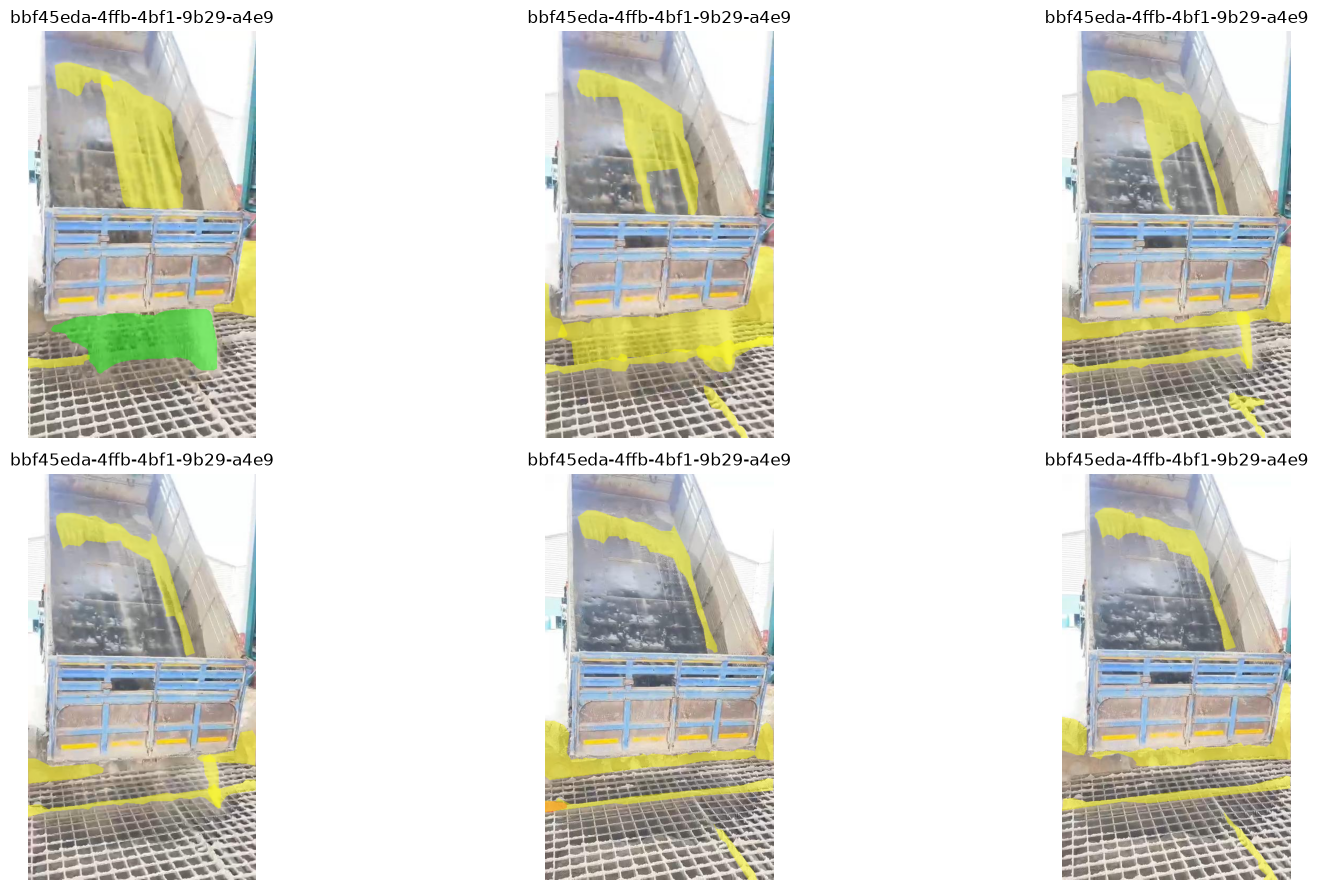

In [12]:
# overlay: best config FN/FP on a few test imgs
best=lb.iloc[0]
print('best config:',best['config'])
# reuse P/BEST — pick union for viz demo on worst-FN images
imgs=sorted(GT,key=lambda n:-sum(1 for g in GT[n] if sieve(g)))[:6]
fig,axs=plt.subplots(2,3,figsize=(18,9))
for ax,nm in zip(axs.ravel(),imgs):
    im=cv2.cvtColor(cv2.imread(str(TI/nm)),cv2.COLOR_BGR2RGB)
    ov=im.copy(); used=set()
    keep=[g for g in GT[nm] if sieve(g)]
    for p in sorted(BEST[nm],key=lambda x:-x['conf']):
        if p['conf']<0.25: continue
        bj,bv=-1,0.
        for j,g in enumerate(keep):
            if j in used or g['cls']!=p['cls']: continue
            v=iou(p['mask'],g['mask'])
            if v>bv: bv,bj=v,j
        col=(0,255,0) if bv>=0.5 else (255,0,0)
        if bv>=0.5: used.add(bj)
        ov[p['mask']]=0.55*np.array(ov[p['mask']])+0.45*np.array(col)
    for j,g in enumerate(keep):
        if j not in used: ov[g['mask']]=0.55*np.array(ov[g['mask']])+0.45*np.array([255,255,0])
    ax.imshow(ov.astype(np.uint8)); ax.set_title(nm[:28]); ax.axis('off')
plt.tight_layout(); plt.show()